In [40]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

## Connecting to Google Drive

In [41]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:

df = pd.read_csv('/content/drive/MyDrive/DataSets/Churn_Modelling.csv')

df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## Understanding data and relations

In [43]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [44]:
df.describe()



,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [45]:
df['Exited'].value_counts()


,count
Exited,
0,7963
1,2037


In [46]:
df['Geography'].value_counts()


,count
Geography,
France,5014
Germany,2509
Spain,2477


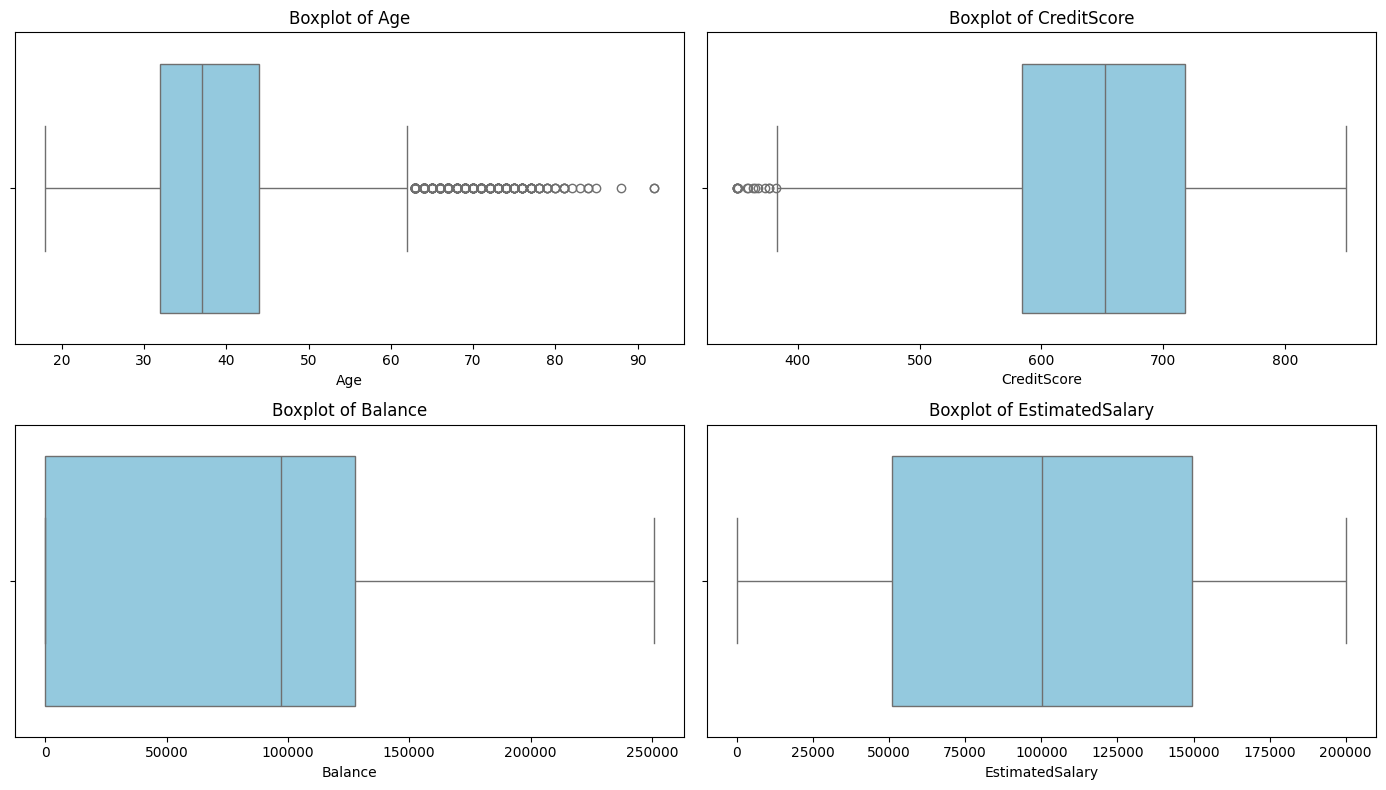

In [47]:

num_cols = ['Age', 'CreditScore', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()


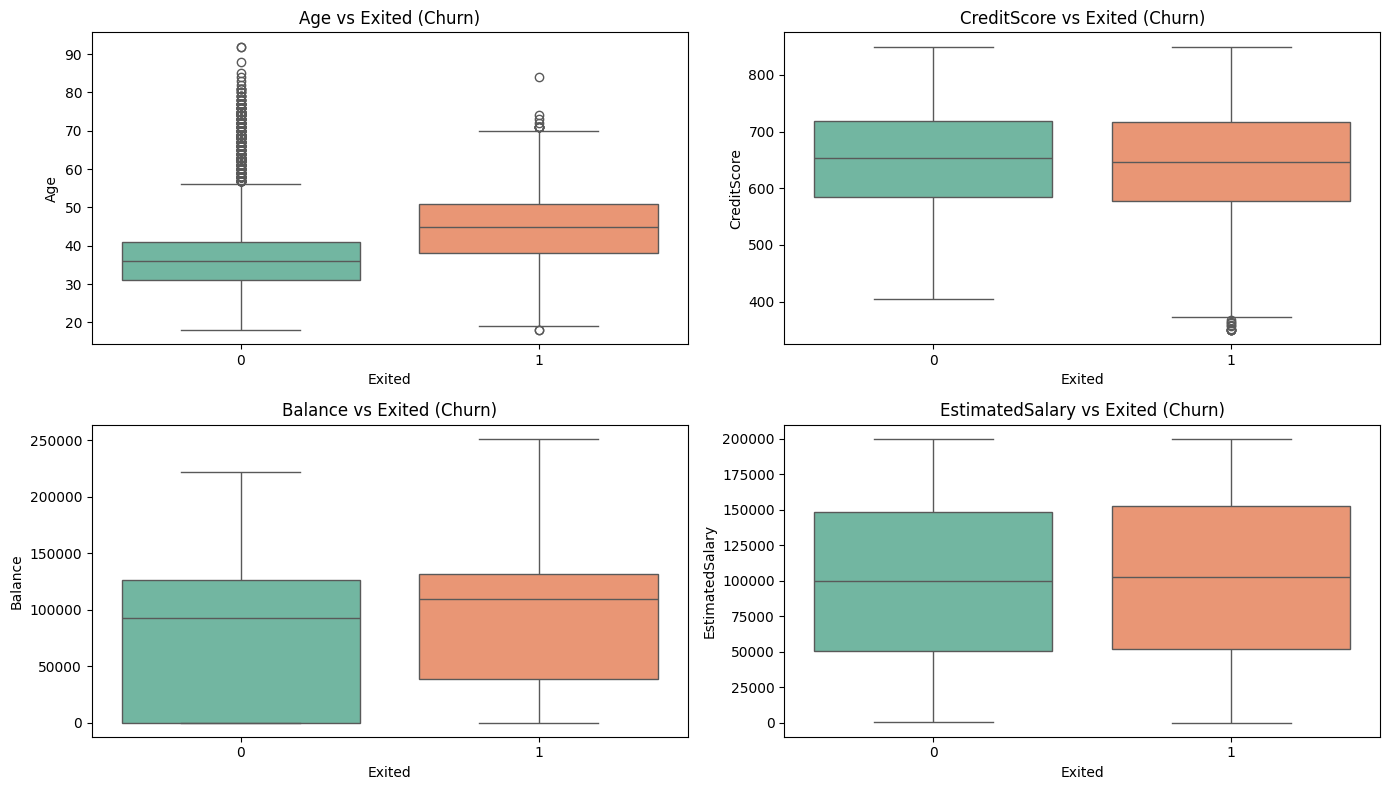

In [48]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Exited', y=col, data=df, hue='Exited', palette='Set2', legend=False)
    plt.title(f'{col} vs Exited (Churn)', fontsize=12)

plt.tight_layout()
plt.show()

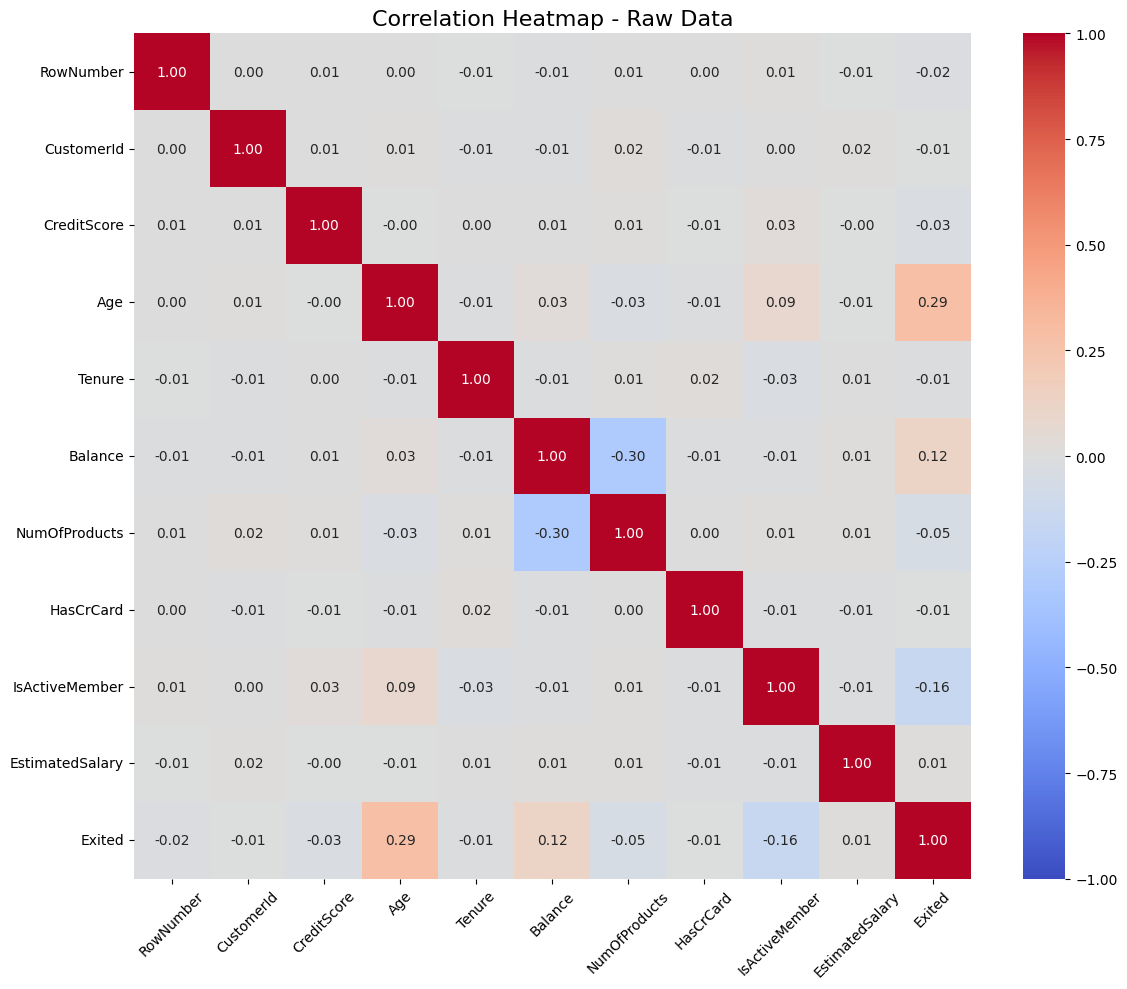

In [49]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 10))


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Correlation Heatmap - Raw Data', fontsize=16)
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

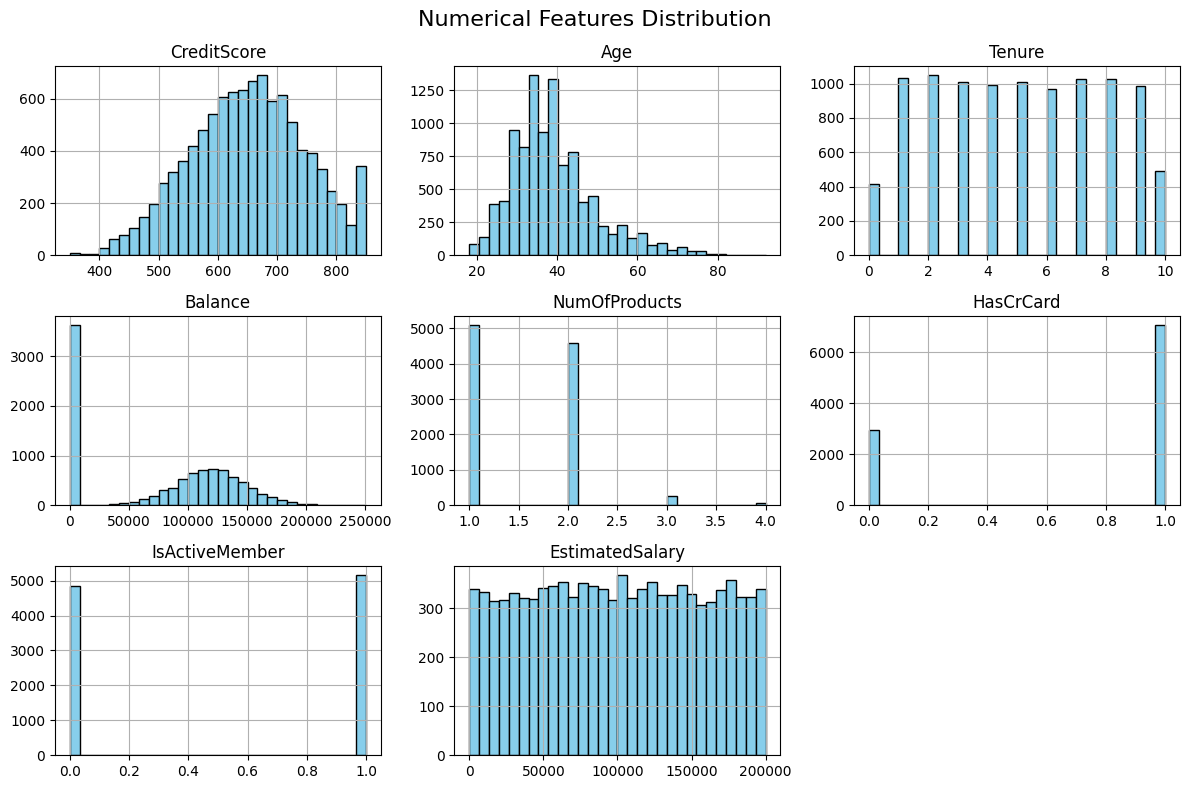

In [50]:
num_cols = df.select_dtypes(include=np.number).columns.drop(['RowNumber', 'CustomerId', 'Exited'], errors='ignore')

df[num_cols].hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Numerical Features Distribution", fontsize=16)
plt.tight_layout()
plt.show()



## Preprocessing

In [51]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['Exited','RowNumber','CustomerId','Surname'],axis=1)
y = df['Exited']

x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,stratify=y,train_size=0.8)

In [54]:

from sklearn.preprocessing import OneHotEncoder

cat_cols = []
for col in x_train.columns:
    if x_train[col].dtype == 'object':
        cat_cols.append(col)

onh=OneHotEncoder(sparse_output=False,drop='first')
encoded_train=onh.fit_transform(x_train[cat_cols])
encoded_test=onh.transform(x_test[cat_cols])



In [55]:
from sklearn.preprocessing import StandardScaler

num_cols = []
for col in x_train.columns:
    if x_train[col].dtype != 'object':
        num_cols.append(col)


scaler=StandardScaler()
x_train_num_scaled=scaler.fit_transform(x_train[num_cols])
x_test_num_scaled=scaler.transform(x_test[num_cols])




In [56]:
x_train_processed = np.c_[x_train_num_scaled, encoded_train]
x_test_processed = np.c_[x_test_num_scaled, encoded_test]

## Logistic Regression

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    PrecisionRecallDisplay
)

lr_model = LogisticRegression(random_state=42, max_iter=1000,class_weight='balanced',n_jobs=-1)
lr_model.fit(x_train_processed, y_train)


y_val_pred = cross_val_predict(lr_model, x_train_processed, y_train, cv=5, method='predict')

cv_precision = precision_score(y_train, y_val_pred)
cv_recall = recall_score(y_train, y_val_pred)
cv_f1 = f1_score(y_train, y_val_pred)

print("=== Logistic Regression Metrics ===")
print(f"training acc      : {lr_model.score(x_train_processed,y_train):.4f}")
print(f"CV Precision      : {cv_precision:.4f}")
print(f"CV Recall         : {cv_recall:.4f}")
print(f"CV F1-Score       : {cv_f1:.4f}")



=== Logistic Regression Metrics ===
training acc      : 0.7106
CV Precision      : 0.3799
CV Recall         : 0.6871
CV F1-Score       : 0.4893


## SVC

In [58]:
from sklearn.svm import SVC


svc_model = SVC(C=0.5,kernel='rbf', class_weight='balanced', random_state=42)
svc_model.fit(x_train_processed, y_train)

y_val_pred = cross_val_predict(svc_model, x_train_processed, y_train, cv=5, method='predict')

cv_precision = precision_score(y_train, y_val_pred)
cv_recall = recall_score(y_train, y_val_pred)
cv_f1 = f1_score(y_train, y_val_pred)

print("=== SVC Metrics ===")
print(f"CV Precision      : {cv_precision:.4f}")
print(f"CV Recall         : {cv_recall:.4f}")
print(f"CV F1-Score       : {cv_f1:.4f}")

=== SVC Metrics ===
CV Precision      : 0.5004
CV Recall         : 0.7540
CV F1-Score       : 0.6016


## Random Forest

In [59]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=200,min_samples_leaf=2,min_samples_split=3,random_state=42,max_depth=10, class_weight='balanced', n_jobs=-1)
rf_model.fit(x_train_processed, y_train)

y_val_pred = cross_val_predict(rf_model, x_train_processed, y_train, cv=5, method='predict')

cv_precision = precision_score(y_train, y_val_pred)
cv_recall = recall_score(y_train, y_val_pred)
cv_f1 = f1_score(y_train, y_val_pred)

print("=== Random Forest Metrics ===")
print(f"training acc      : {rf_model.score(x_train_processed,y_train):.4f}")
print(f"CV Precision      : {cv_precision:.4f}")
print(f"CV Recall         : {cv_recall:.4f}")
print(f"CV F1-Score       : {cv_f1:.4f}")

=== Random Forest Metrics ===
training acc      : 0.9006
CV Precision      : 0.6078
CV Recall         : 0.6503
CV F1-Score       : 0.6283


## Gradient boosting

In [60]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=200,learning_rate=0.01,min_samples_leaf=2,min_samples_split=3,max_depth=3,random_state=42)
gb_model.fit(x_train_processed, y_train)

y_val_pred = cross_val_predict(gb_model, x_train_processed, y_train, cv=5, method='predict')

cv_precision = precision_score(y_train, y_val_pred)
cv_recall = recall_score(y_train, y_val_pred)
cv_f1 = f1_score(y_train, y_val_pred)

print("=== Gradient Boosting Metrics ===")
print(f"CV Precision      : {cv_precision:.4f}")
print(f"CV Recall         : {cv_recall:.4f}")
print(f"CV F1-Score       : {cv_f1:.4f}")

=== Gradient Boosting Metrics ===
CV Precision      : 0.8455
CV Recall         : 0.3491
CV F1-Score       : 0.4941


## XG boost

[0]	validation_0-logloss:0.58947	validation_1-logloss:0.59984
[1]	validation_0-logloss:0.52885	validation_1-logloss:0.54621
[2]	validation_0-logloss:0.48994	validation_1-logloss:0.50902
[3]	validation_0-logloss:0.46347	validation_1-logloss:0.48654
[4]	validation_0-logloss:0.44531	validation_1-logloss:0.47412
[5]	validation_0-logloss:0.43056	validation_1-logloss:0.46476
[6]	validation_0-logloss:0.41656	validation_1-logloss:0.45410
[7]	validation_0-logloss:0.40288	validation_1-logloss:0.44918
[8]	validation_0-logloss:0.39501	validation_1-logloss:0.44307
[9]	validation_0-logloss:0.38912	validation_1-logloss:0.44188
[10]	validation_0-logloss:0.38326	validation_1-logloss:0.43681
[11]	validation_0-logloss:0.37708	validation_1-logloss:0.43570
[12]	validation_0-logloss:0.37337	validation_1-logloss:0.43535
[13]	validation_0-logloss:0.36896	validation_1-logloss:0.43396
[14]	validation_0-logloss:0.36046	validation_1-logloss:0.43092
[15]	validation_0-logloss:0.35700	validation_1-logloss:0.42921
[1

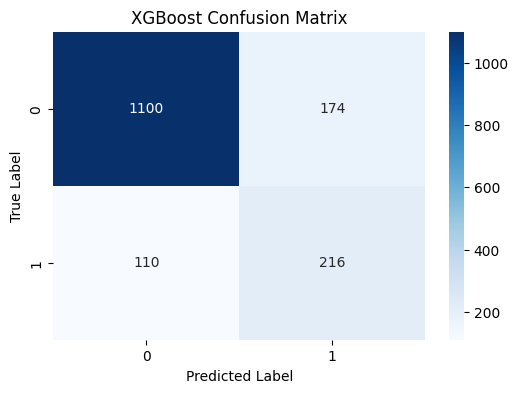

In [63]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

X_tr, X_val, y_tr, y_val = train_test_split(
    x_train_processed, 
    y_train, 
    test_size=0.2, 
    stratify=y_train, 
    random_state=42
)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos,
    random_state=42,
    n_estimators=5000,
    early_stopping_rounds=30,
    n_jobs=-1
)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[
        (X_tr, y_tr),
        (X_val, y_val)
    ],
    verbose=True
)

y_val_pred = xgb_model.predict(X_val)

print("\n=== XGBoost Evaluation Metrics ===")
print("Train Accuracy :", xgb_model.score(X_tr, y_tr))
print("Valid Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision      :", precision_score(y_val, y_val_pred))
print("Recall         :", recall_score(y_val, y_val_pred))
print("F1             :", f1_score(y_val, y_val_pred))
print("ROC-AUC        :", roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1]))

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()